# Combining Parkinson's disease taxonomic analyses

In this notebook we aim to imitate the analyses in ["`ABaCo` demo: Parkinson’s disease gut microbiome"](https://mona-abaco.readthedocs.io/en/latest/tutorial/demo-parkinson.html) where the aim was to "integrate the 9 studies while preserving key distinctions from the two patient states (Parkinson’s v.s. Healthy)."

```{margin}
After clicking the "Activate Notebook" button you can run the cells in this browser. Alternatively, you can also click on the 🚀 to launch in colab or binder.
```
<button title="Make live" style="display:inline-flex;align-items:center;gap:0.4rem;padding:0.5rem 1rem;border:0;border-radius:20px;background:linear-gradient(135deg,#0f766e,#14b8a6);color:white;cursor:pointer;font-size:1rem;" class="thebe-button" onclick="initThebeSBT()">Activate Notebook</button>

---

In [1]:
# uncomment if colab
# !pip install mgnipy

## Curating the taxonomic datasets with metadata

### Searching for studies using `MGnifier`

To start we configure our MGnipy client and access the MGnify API Studies resource.

We will filter our query to studies of the gut microbiome that mention "parkinson"s disease.

We can preview the resulting query urls via `.explain()`

In [2]:
from mgnipy import MGnipy

# Initialize MGnipy with a cache directory
MG = MGnipy(cache_dir="downloads")

# Search for studies related to Parkinson's disease in the human gut microbiome
pd_studies = MG.studies(
    search="parkinson",
    biome_lineage="root:Host-associated:Human:Digestive system:Large intestine:Fecal",
)

# Show all of the request urls for the search i.e., the query set
pd_studies.explain()

https://www.ebi.ac.uk/metagenomics/api/v2/studies?biome_lineage=root%3AHost-associated%3AHuman%3ADigestive+system%3ALarge+intestine%3AFecal&search=parkinson&page=1


looks good. we can proceed with actually executing the list query/queries via .get(). To enrich our list of studies with metadata details we can do this in bulk using `.enrich_details()` or asynchronously via `.aenrich_details()`

In [3]:
# as http client manager
async with MG:
    # populate study list
    await pd_studies.aget()
    # enrich study list with metadta
    await pd_studies.aenrich_details()

# can view as pandas or even save to file if you prefer
study_meta = pd_studies.metadata
# taking a look
study_meta.to_pandas(expand_nested_dicts=True)

Enriching study details: 100%|██████████| 8/8 [00:00<00:00, 548.33it/s]


,accession,ena_accessions,title,updated_at,downloads,first_accession,metadata__study_name,metadata__center_name,metadata__study_title,metadata__study_accession,metadata__study_description,metadata__secondary_study_accession,biome__biome_name,biome__lineage
0,MGYS00006121,"[ERP142200, PRJEB57228]",Dietary intervention of people with Parkinson'...,2026-05-28T15:47:01.432000+00:00,"[{'file_type': 'tsv', 'download_type': 'Taxono...",ERP142200,NaN,NaN,NaN,NaN,NaN,NaN,Fecal,root:Host-associated:Human:Digestive system:La...
1,MGYS00005755,"[PRJNA510730, SRP173877]",Microbiota composition of Parkinson's disease ...,2026-05-06T11:35:50.490000+00:00,"[{'file_type': 'tsv', 'download_type': 'Taxono...",SRP173877,NaN,NaN,NaN,NaN,NaN,NaN,Fecal,root:Host-associated:Human:Digestive system:La...
2,MGYS00005129,"[ERP109659, PRJEB27564]",Gut microbiota in Parkinson's disease: tempora...,2026-05-06T12:25:31.349000+00:00,"[{'file_type': 'tsv', 'download_type': 'Taxono...",ERP109659,Parkinson's disease gut microbiota follow-up,Institute of Biotechnology;University of Helsi...,Gut microbiota in Parkinson's disease: tempora...,PRJEB27564,Aiming to explore the temporal stability of gu...,ERP109659,Fecal,root:Host-associated:Human:Digestive system:La...
3,MGYS00006759,"[ERP146353, PRJEB61255]",EMG produced TPA metagenomics assembly of PRJN...,2026-05-28T15:47:02.660000+00:00,"[{'file_type': 'tsv', 'download_type': 'Taxono...",ERP146353,NaN,NaN,NaN,NaN,NaN,NaN,Fecal,root:Host-associated:Human:Digestive system:La...
4,MGYS00005130,"[ERP112853, PRJEB30401]",Gut Microbiome Alterations Drive Distinct Meta...,2026-05-06T10:02:48.163000+00:00,"[{'file_type': 'tsv', 'download_type': 'Taxono...",ERP112853,Gut Microbiome and Parkinson's Disease,University of Cagliari,Gut Microbiome Alterations Drive Distinct Meta...,PRJEB30401,Parkinson's disease is a neurodegenerative dis...,ERP112853,Fecal,root:Host-associated:Human:Digestive system:La...
5,MGYS00005601,"[ERP113090, PRJEB30615]",Identification of Intestinal Bacterial Taxa wi...,2026-05-28T15:47:01.054000+00:00,"[{'file_type': 'tsv', 'download_type': 'Taxono...",ERP113090,NaN,NaN,NaN,NaN,NaN,NaN,Fecal,root:Host-associated:Human:Digestive system:La...
6,MGYS00006760,"[ERP148661, PRJEB63522]",EMG produced TPA metagenomics assembly of PRJN...,2026-05-28T15:47:02.672000+00:00,"[{'file_type': 'tsv', 'download_type': 'Taxono...",ERP148661,NaN,NaN,NaN,NaN,NaN,NaN,Fecal,root:Host-associated:Human:Digestive system:La...
7,MGYS00001650,"[ERP004264, PRJEB4927]",Alterations of the Fecal Microbiome in Parkins...,2026-05-28T15:47:02.598000+00:00,"[{'file_type': 'tsv', 'download_type': 'Taxono...",ERP004264,Fecal Microbiome in Parkinson's Disease,Institute of Biotechnology;University of Helsi...,Alterations of the Fecal Microbiome in Parkins...,PRJEB4927,"In the course of Parkinson’s disease (PD), the...",ERP004264,Fecal,root:Host-associated:Human:Digestive system:La...


Now that we found some studies that match our sesarch criteria, we can take a look at their datasets. 

---

### Using `MGazine` to access the study datasets

we can access the mgazine of datasets (kinda like a list of available datasets) via `.datasets` attribute. The study details we retrieved above will also be passed on to the mgazine

In [4]:
# access mgazine
MZ = pd_studies.datasets

# take a look
print(MZ)

MGazine containing:
- MGnify pipeline versions: ['v3', 'v4_1', 'v5', 'v6']
- Number of downloads: 72
- Short descriptions: ['Complete GO annotation',
 'DwC-Ready summary of 16S-V3-V4 ASV taxonomies using -PR2 as ref DB',
 'DwC-Ready summary of 16S-V3-V4 ASV taxonomies using -SILVA as ref DB',
 'DwC-Ready summary of closed-ref taxonomies using ITSoneDB as ref DB',
 'DwC-Ready summary of closed-ref taxonomies using PR2 as ref DB',
 'DwC-Ready summary of closed-ref taxonomies using SILVA-LSU as ref DB',
 'DwC-Ready summary of closed-ref taxonomies using SILVA-SSU as ref DB',
 'GO slim annotation',
 'InterPro matches',
 'Phylum level taxonomies',
 'Phylum level taxonomies LSU',
 'Phylum level taxonomies SSU',
 'Summary of DADA2-PR2 taxonomies',
 'Summary of DADA2-SILVA taxonomies',
 'Summary of ITSoneDB taxonomies',
 'Summary of PR2 taxonomies',
 'Summary of SILVA-LSU taxonomies',
 'Summary of SILVA-SSU taxonomies',
 'Taxonomic assignments',
 'Taxonomic assignments LSU',
 'Taxonomic assign

Notice in "Nonempty metadata sets" we can see that the study details we collected [above](#searching-for-studies-using-mgnifier) are preserved in the mgazine. 
```{toggle}
The `mgnify_studies` attribute is a `MGnifyMetadata` object so contains all the same methods for viewing e.g.: 
- `MZ_SSU.mgnify_studies.to_pandas(expand_nested_dicts=True)`
- `... .to_list()`
- `... .to_polars()`
- `... .records()`
- etc.

Later on in [Using MGnetizer to colllect more metadata](#using-mgnetizer-to-collect-more-metadata) we will assign additional sets of metadata to `.mgnify_runs` and `.biosamples_metadata` which will also convert the lists of records into a MGnifyMetadata object
```

#### Filtering the dataset list

We can filter by the pipeline version and short descriptions of the datasets. 

For the ABaCo demo we will use the taxonomic analyses and we will use v4 onwards due to differences in pipeline versions and specifically SILVA databases that were used for the taxonomic analysis


In [5]:
# we can filter by passing as index
V5 = MZ["v5"]["Taxonomic assignments SSU"]
V6 = MZ["Summary of SILVA-SSU taxonomies"]

print(V5, V6)

MGazine containing:
- MGnify pipeline versions: ['v5']
- Number of downloads: 4
- Short descriptions: ['Taxonomic assignments SSU']
- Nonempty metadata sets: .mgnify_studies
 MGazine containing:
- MGnify pipeline versions: ['v6']
- Number of downloads: 3
- Short descriptions: ['Summary of SILVA-SSU taxonomies']
- Nonempty metadata sets: .mgnify_studies



#### Combining dataset lists

In [6]:
# can add magazines
MZ_SSU = V5 + V6

# print still works
print(MZ_SSU)

MGazine containing:
- MGnify pipeline versions: ['v5', 'v6']
- Number of downloads: 7
- Short descriptions: ['Summary of SILVA-SSU taxonomies', 'Taxonomic assignments SSU']
- Nonempty metadata sets: .mgnify_studies



Now that we have filtered our list of datasets a bit, let's actually get and merge the taxonomic datasets. 

---

#### (Lazy)loading into one taxonomic dataset

Currently availble in mgnipy are special MGazines for handling taxonomic assignment datasets in the classic taxa x sample/run format `TaxaMGazine` or in Darwin core-ready format `DWCTaxaMGazine`

we can also access these from an existing MGazine instance via `.taxonomic` or `.taxonomic_dwc_ready`

In [7]:
taxo = MZ_SSU.taxonomic

TaxaMGazine containing:
- MGnify pipeline versions: ['v5', 'v6']
- Number of downloads: 7
- Short descriptions: ['Summary of SILVA-SSU taxonomies', 'Taxonomic assignments SSU']
- Nonempty metadata sets: .mgnify_studies
-----------------------
Next steps: Use `.load()` to initialize.



now we can load the datasets as `polars.LazyFrame`

In [8]:
# lazyload the mgnify taxanomic assignments datasets
taxo.load()

# calling to_pandas or to_polars will collect the data and return a dataframe
taxo.to_pandas().head()

,taxonomy,ERZ15614030,ERZ15614040,ERZ15614050,ERZ15614060,ERZ15614021,ERZ15614031,ERZ15614041,ERZ15614051,ERZ15614061,...,ERR3006049,ERR3006050,ERR3006051,ERR3006052,ERR3006053,ERR3006054,ERR3006055,ERR3006056,ERR3006057,ERR3006058
0,sk__Archaea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,sk__Archaea;k__;p__Candidatus_Thermoplasmatota...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sk__Archaea;k__;p__Candidatus_Thermoplasmatota...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sk__Archaea;k__;p__Candidatus_Thermoplasmatota...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,sk__Archaea;k__;p__Candidatus_Thermoplasmatota...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


additionally there is a method `.taxonomic_metadata()` that parses "taxonomy" into the taxonomic ranks, returning as pandas or polars dataframe which is configured via arg `df_engine=`. The default is pandas.

also any run and sample metadata relevant to the observations (i.e., by run accessions) can be merged and viewed using `.obs_metadata()` again as polars or pandas dataframes. As we know metadata() for the observations in the taxonomic mgazine is not available:

In [9]:
# see first 5 sample's metadata
display(taxo.obs_metadata().head())

# recall the "Nonempty metadata set:"
print(taxo)

""
_mgnipy_runs_accs
ERR2730148
ERR2730149
ERR2730150
ERR2730151
ERR2730152


TaxaMGazine containing:
- MGnify pipeline versions: ['v5', 'v6']
- Number of downloads: 7
- Short descriptions: ['Summary of SILVA-SSU taxonomies', 'Taxonomic assignments SSU']
- Nonempty metadata sets: .mgnify_studies



if we recall [from earlier](#using-mgazine-to-access-the-study-datasets) and again in the print statement, we only had `.mgnify_studies` enriched. 

We still need to enrich with run and/or sample metadata, which we will do next :) 

---

### Using `MGnetizer` to collect more metadata

MGnetizer is designed to retrieve the rich metadata from MGnify for a given list of MGnify accessions/ids.

First we get the ids to pass on 

In [10]:
# separate run and assembly ids
runs_ids = [
    x for x in taxo.runs_accessions if x.startswith("ERR") or x.startswith("SRR")
]
assembly_ids = [x for x in taxo.runs_accessions if x.startswith("ERZ")]
print(f"Runs: {len(runs_ids)}")
print(f"Assembly: {len(assembly_ids)}")

Runs: 876
Assembly: 952


Now we will instantiate the MGnetizers and pass the accessions/ids. 

In [11]:
# initialize mgnetizer for runs and assemblies
mnet_run = MG.mgnetizer(resource="run", all_ids=runs_ids)
mnet_acc = MG.mgnetizer(resource="assembly", all_ids=assembly_ids)
print(mnet_run, mnet_acc)

MGnetizer for resource 'run' with 876 ids. 
Progress: 0 ids. 
Detail proxy: RunDetail 
Cache directory: downloads/4318aa6ab908c5817a9ab02f4a926f726ee98863655922ca623e03b6b19e4403 
 MGnetizer for resource 'assembly' with 952 ids. 
Progress: 0 ids. 
Detail proxy: AssemblyDetail 
Cache directory: downloads/cb192e1c57deabd60d7bb6e86d273fcff987cfb161e8b3ad833051dfe526a75e 



In [12]:
# now making the API calls with context manager
async with MG:
    await mnet_run.aenrich(limit=None)
    await mnet_acc.aenrich(limit=None)

Enriching metadata from MGnify: 100%|██████████| 952/952 [00:00<?, ?it/s]


In [13]:
# we can combine the metadata from both runs and assemblies into one MGnifyMetadata
run_metadata = mnet_run.metadata + mnet_acc.metadata

# like any other MGnifyMetdata obj we can view as list, pd, pl
run_metadata.to_pandas().head()

,experiment_type,instrument_model,instrument_platform,sample,study,accession,sample_accession,study_accession,updated_at,run_accession,reads_study_accession,assembly_study_accession,assembler_name,assembler_version,metadata,status
0,None,None,None,None,None,ERZ24771296,SAMN28061989,None,2026-05-01T18:11:09.343000+00:00,SRR19064826,None,MGYS00006759,None,None,{},"{'assembly_failed': False, 'assembly_blocked':..."
1,Amplicon,None,None,"{'accession': 'SAMEA5206906', 'ena_accessions'...","{'accession': 'MGYS00005601', 'ena_accessions'...",ERR3046437,SAMEA5206906,MGYS00005601,None,None,None,None,None,None,None,None
2,Amplicon,None,None,"{'accession': 'SAMEA5206934', 'ena_accessions'...","{'accession': 'MGYS00005601', 'ena_accessions'...",ERR3046464,SAMEA5206934,MGYS00005601,None,None,None,None,None,None,None,None
3,None,None,None,None,None,ERZ24771358,SAMN28061884,None,2026-05-01T18:10:52.394000+00:00,SRR19064859,None,MGYS00006759,None,None,{},"{'assembly_failed': False, 'assembly_blocked':..."
4,None,None,None,None,None,ERZ19289351,SAMN22185062,None,2026-05-01T18:21:32.635000+00:00,SRR16279992,None,MGYS00006760,None,None,{},"{'assembly_failed': False, 'assembly_blocked':..."


if wanting to do some cleaning, do so and then save back to `.data`

below I clean as a pandas dataframe and then convert back to list of dicts for the MGazine

In [14]:
df_run = run_metadata.to_pandas()
df_run["study_accession"] = df_run["study_accession"].fillna(
    df_run["assembly_study_accession"]
)
df_run = df_run.drop(columns=["assembly_study_accession"])

Optionally we can pass this metadata back to a MGazine to help with dataset curation:

In [15]:
# now back to TaxaMGazine instance as list of records
taxo.mgnify_runs = df_run.to_dict(orient="records")

# and now
print(taxo)

# also the metadata is updated
taxo.obs_metadata().info()

TaxaMGazine containing:
- MGnify pipeline versions: ['v5', 'v6']
- Number of downloads: 7
- Short descriptions: ['Summary of SILVA-SSU taxonomies', 'Taxonomic assignments SSU']
- Nonempty metadata sets: .mgnify_runs, .mgnify_studies

<class 'pandas.core.frame.DataFrame'>
Index: 1828 entries, ERR2730148 to SRR8352125
Data columns (total 28 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   experiment_type                            876 non-null    object 
 1   instrument_model                           0 non-null      object 
 2   instrument_platform                        0 non-null      object 
 3   sample_accession                           1828 non-null   object 
 4   study_accession                            1828 non-null   object 
 5   updated_at                                 952 non-null    object 
 6   run_accession                              952 non-null    object 
 

However, the available run/sample metadata is not consistent for all e.g. sample__sample_title which has lots missing. We can try to get additional sample metadata from the BioSamples database. 

---

### Collecting even more sample metadata using `BioSampler`
BioSampler is designed to retrieve the rich sample metadata from BioSamples for a list of Run or Sample ENA accessions.


we again start from the mgnipy instance to automatically pass on the configuration 

In [16]:
# getting list of sample ids to go to BioSamples
sample_ids = taxo.mgnify_runs.to_pandas()["sample_accession"].to_list()

bios = MG.biosampler(sample_ids=sample_ids)

print(bios)

BioSampler with 1828 sample_ids. 
Progress: 0 ids. 
Cache directory: downloads/300c23211f66966a7d9306ef28fba3cc6e8e3c77a8eb7a58805264f5785a5a5f 



In [17]:
with bios:
    await bios.aenrich(limit=None, incl_ena=False)

Enriching biosamples: 100%|██████████| 1828/1828 [00:00<?, ?it/s]


and we can also pass this metadata to the TaxaMGazine instance to `.biosamples_metadata` for merging:

In [18]:
taxo.biosamples_metadata = bios.metadata.to_list(drop_duplicates=True)
print(taxo)

TaxaMGazine containing:
- MGnify pipeline versions: ['v5', 'v6']
- Number of downloads: 7
- Short descriptions: ['Summary of SILVA-SSU taxonomies', 'Taxonomic assignments SSU']
- Nonempty metadata sets: .mgnify_runs, .mgnify_studies, .biosamples_metadata



and now if we look at the observations metadata we have even more possible annotations

In [19]:
taxo.obs_metadata().info()

<class 'pandas.core.frame.DataFrame'>
Index: 1828 entries, ERR2730148 to SRR8352125
Columns: 153 entries, experiment_type to Day_of_stool_collection_excess_gas
dtypes: float64(1), int64(1), object(151)
memory usage: 2.1+ MB


### Data cleaning based on sample (obs) metadata 

inspecting the metadata we found disease status distrbuted between the following columns: 

In [20]:
disease_status_columns = {
    "host_phenotype": {"Y": ["Parkinson's Disease"], "N": ["Healthy Control"]},
    "host disease status": {
        "Y": ["Parkinson's disease", "Parkinson's Disease [DOID:14330]"],
        "N": ["healthy control", "Healthy [NCIT:C115935]"],
    },
    "parkinson": {"Y": ["yes"], "N": ["no"]},
    "Case_status": {"Y": ["PD"], "N": ["Control"]},
}

# filter out samples with no disease status metadata
df_obs = taxo.obs_metadata().copy()
df_obs_filt = df_obs[df_obs[disease_status_columns.keys()].notna().any(axis=1)].copy()
print(f"Filtered down to {len(df_obs_filt)} samples with disease status metadata.")

# create a new column to indicate if the sample has Parkinson's disease or not
df_obs_filt["has_parkinsons_disease"] = None
for col in disease_status_columns:
    df_obs_filt[col] = df_obs_filt[col].map(
        lambda x: (
            "Y"
            if x in disease_status_columns[col]["Y"]
            else ("N" if x in disease_status_columns[col]["N"] else None)
        )
    )
df_obs_filt["has_parkinsons_disease"] = df_obs_filt.loc[
    :, disease_status_columns.keys()
].apply(
    lambda x: "Y" if "Y" in x.values else ("N" if "N" in x.values else None), axis=1
)
print(
    f"PD samples: {len(df_obs_filt[df_obs_filt['has_parkinsons_disease'] == 'Y'])}, Non-PD samples: {len(df_obs_filt[df_obs_filt['has_parkinsons_disease'] == 'N'])}"
)

# list of studies
filt_studies = df_obs_filt["study_accession"].unique()
print(f"Studies: {filt_studies}")

Filtered down to 1458 samples with disease status metadata.
PD samples: 901, Non-PD samples: 557
Studies: ['MGYS00005129' 'MGYS00005601' 'MGYS00006121' 'MGYS00006759'
 'MGYS00005755']


We will only include the studies with samples with disease status metadata and will move on with this demonstration. 

One way we can go about filtering our taxonomic datasets is repeating the above steps but starting with MGnetizer instead of searching Studies resource with MGnifier:

In [21]:
# collect the studies metadata and datasets for the filtered studies
new_mnet = MG.mgnetizer(resource="study", all_ids=filt_studies)
with MG:
    new_mnet.enrich()

# accessing datasets of the filtered studies
new_mz = new_mnet.datasets
V5 = new_mz["v5"]["Taxonomic assignments SSU"]
V6 = new_mz["Summary of SILVA-SSU taxonomies"]

# filter datasets to taxonomic 
new_new_mz = V5 + V6
new_taxo = new_new_mz.taxonomic
new_taxo.load()

# also add on the observation metadata that we had prepared just before
new_taxo.obs = df_obs_filt.reset_index().to_dict(orient="records")

Enriching metadata from MGnify: 100%|██████████| 5/5 [00:00<?, ?it/s]

TaxaMGazine containing:
- MGnify pipeline versions: ['v5', 'v6']
- Number of downloads: 5
- Short descriptions: ['Summary of SILVA-SSU taxonomies', 'Taxonomic assignments SSU']
- Nonempty metadata sets: .mgnify_studies
-----------------------
Next steps: Use `.load()` to initialize.



and the TaxaMGazine can handle the rest and we can export to_anndata() if we want

In [22]:
ad_tax = new_taxo.to_anndata()
ad_tax

'Summary of SILVA-SSU taxonomies' may be used for e.g., caching, `long_short_mapping`.
/Users/anglup/GitHub/mgnipy/.venv/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: X converted to numpy array with dtype float64
  return fn(*args_all, **kw)


AnnData object with n_obs × n_vars = 1458 × 2828
    obs: 'experiment_type', 'instrument_model', 'instrument_platform', 'sample_accession', 'study_accession', 'updated_at', 'run_accession', 'reads_study_accession', 'assembler_name', 'assembler_version', 'status', 'sample__accession', 'sample__ena_accessions', 'sample__sample_title', 'sample__biome', 'sample__updated_at', 'study__accession', 'study__ena_accessions', 'study__title', 'study__updated_at', 'study__biome.biome_name', 'study__biome.lineage', 'study__metadata.study_name', 'study__metadata.center_name', 'study__metadata.study_title', 'study__metadata.study_accession', 'study__metadata.study_description', 'study__metadata.secondary_study_accession', 'GivenID', 'RunID', 'SRA accession', 'name', 'taxid', 'ENA first public', 'ENA-CHECKLIST', 'External Id', 'INSDC center name', 'INSDC last update', 'INSDC status', 'Submitter Id', 'broad-scale environmental context', 'collection date', 'description', 'environmental medium', 'geograph

okay thanks for the help mgnipy and thank you MGnify for the analyses and metadata! From here out we further pre-process the data including cleaning and normalising the taxonomic matrix, followed by ABaCo for batch correction between the studies. 

## Preprocessing the counts

and we will agglomerate to Genus level

In [23]:
import numpy as np
import scanpy as sc

from mgnipy._models.constants.tax_ranks import SILVA_TAX_RANKS

# quick cleaning
# add filled na layer
ad_tax.layers["filled_na"] = ad_tax.to_df().fillna(0)
# drop samples if library count is less than median
ad_filt = ad_tax[
    ad_tax.to_df(layer="filled_na").sum(axis=1)
    >= ad_tax.to_df(layer="filled_na").sum(axis=1).median()
]
# calc total counts per sample
total_counts = ad_filt.layers["filled_na"].sum(axis=1)
# agglom to genus level (pruning then agg)
pruned = ad_filt[:, ((ad_filt.var["Genus"] != "NA") & (ad_filt.var["Species"] != "NA"))]
# to avoid memory issues..
pruned.var["ranks_to_genus"] = pruned.var[SILVA_TAX_RANKS[:-1]].agg(";".join, axis=1)
# agg with scanpy
ad_genus = sc.get.aggregate(
    pruned,
    by="ranks_to_genus",
    func="sum",
    axis="var",
    layer="filled_na",
)
# getting the relabund
ad_genus.layers["total_counts"] = np.array([total_counts] * ad_genus.n_vars).T
ad_genus.layers["rel_abund"] = ad_genus.layers["sum"] / ad_genus.layers["total_counts"]
# prevalence threshold of 10%
ad_genus_filt = ad_genus[
    :, (ad_genus.to_df(layer="sum") > 0).sum(axis=0) >= (ad_genus.n_vars * 0.1)
]
ad_genus_filt.to_df(layer="sum")

/var/folders/3d/vpv9_sk51c584kypm0w04hmh0000gp/T/ipykernel_64050/3059127398.py:19: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  pruned.var["ranks_to_genus"] = pruned.var[SILVA_TAX_RANKS[:-1]].agg(";".join, axis=1)


,Bacteria;NA;Actinobacteria;Coriobacteriia;Coriobacteriales;Atopobiaceae;Olsenella,Bacteria;NA;Actinobacteria;Coriobacteriia;Coriobacteriales;Coriobacteriaceae;Collinsella,Bacteria;NA;Actinobacteria;Coriobacteriia;Eggerthellales;Eggerthellaceae;Raoultibacter,Bacteria;NA;Actinomycetota;Actinomycetes;Bifidobacteriales;Bifidobacteriaceae;Alloscardovia,Bacteria;NA;Actinomycetota;Actinomycetes;Bifidobacteriales;Bifidobacteriaceae;Bifidobacterium,Bacteria;NA;Actinomycetota;Actinomycetes;Bifidobacteriales;Bifidobacteriaceae;Parascardovia,Bacteria;NA;Actinomycetota;Actinomycetes;Bifidobacteriales;Bifidobacteriaceae;Scardovia,Bacteria;NA;Actinomycetota;Actinomycetes;Kitasatosporales;Streptomycetaceae;Streptomyces,Bacteria;NA;Actinomycetota;Actinomycetes;Mycobacteriales;Lawsonellaceae;Lawsonella,Bacteria;NA;Actinomycetota;Actinomycetes;Propionibacteriales;Propionibacteriaceae;Propionibacterium,...,Bacteria;NA;Firmicutes;Clostridia;Clostridiales;Ruminococcaceae;Ruminococcus,Bacteria;NA;Firmicutes;Erysipelotrichia;Erysipelotrichales;Erysipelotrichaceae;Traorella,Bacteria;NA;Pseudomonadota;Betaproteobacteria;Burkholderiales;Oxalobacteraceae;Oxalobacter,Bacteria;NA;Pseudomonadota;Betaproteobacteria;Burkholderiales;Sutterellaceae;Duodenibacillus,Bacteria;NA;Pseudomonadota;Betaproteobacteria;Burkholderiales;Sutterellaceae;Parasutterella,Bacteria;NA;Pseudomonadota;Betaproteobacteria;Burkholderiales;Sutterellaceae;Sutterella,Bacteria;NA;Pseudomonadota;Gammaproteobacteria;Enterobacterales;Enterobacteriaceae;Escherichia,Bacteria;NA;Thermodesulfobacteriota;Desulfovibrionia;Desulfovibrionales;Desulfovibrionaceae;Bilophila,Bacteria;NA;Thermodesulfobacteriota;Desulfovibrionia;Desulfovibrionales;Desulfovibrionaceae;Desulfovibrio,Bacteria;NA;Verrucomicrobiota;Verrucomicrobiae;Verrucomicrobiales;Akkermansiaceae;Akkermansia
_mgnipy_runs_accs,,,,,,,,,,,,,,,,,,,,,
ERR2730148,0.0,0.0,0.0,0.0,590.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,66.0,17.0,0.0,1.0
ERR2730149,0.0,0.0,0.0,0.0,1836.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,80.0,0.0,0.0,4.0
ERR2730150,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,2.0,22.0,0.0,0.0
ERR2730151,0.0,0.0,0.0,1.0,116.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,132.0,4.0,13.0,0.0,0.0
ERR2730152,0.0,0.0,0.0,0.0,31.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,8.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR8352121,0.0,0.0,0.0,0.0,410.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,27.0,1.0,14.0
SRR8352122,0.0,0.0,0.0,6.0,224.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,306.0,276.0,75.0,0.0,6.0
SRR8352123,0.0,0.0,0.0,1.0,309.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,30.0,0.0,0.0,47.0,1625.0,56.0,0.0,10.0


In [24]:
ad_filt.obs["total_counts"] = ad_filt.layers["filled_na"].sum(axis=1)

this = (
    ad_filt.obs[["has_parkinsons_disease", "study_accession", "total_counts"]]
    .merge(ad_filt.to_df(layer="filled_na"), left_index=True, right_index=True)
    .reset_index()
)
this

/var/folders/3d/vpv9_sk51c584kypm0w04hmh0000gp/T/ipykernel_64050/3271838844.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ad_filt.obs["total_counts"] = ad_filt.layers["filled_na"].sum(axis=1)


,_mgnipy_runs_accs,has_parkinsons_disease,study_accession,total_counts,sk__Archaea,sk__Archaea;k__;p__Candidatus_Thermoplasmatota;c__Thermoplasmata,sk__Archaea;k__;p__Candidatus_Thermoplasmatota;c__Thermoplasmata;o__Methanomassiliicoccales,sk__Archaea;k__;p__Candidatus_Thermoplasmatota;c__Thermoplasmata;o__Methanomassiliicoccales;f__Methanomassiliicoccaceae;g__Methanomassiliicoccus,sk__Archaea;k__;p__Candidatus_Thermoplasmatota;c__Thermoplasmata;o__Methanomassiliicoccales;f__Methanomassiliicoccaceae;g__Methanomassiliicoccus;s__Candidatus_Methanomassiliicoccus_intestinalis,sk__Archaea;k__;p__Candidatus_Thermoplasmatota;c__Thermoplasmata;o__Methanomassiliicoccales;f__Methanomethylophilaceae,...,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Fabales;f__Fabaceae;g__Ammopiptanthus;s__Ammopiptanthus_mongolicus,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Fabales;f__Fabaceae;g__Arachis,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Fabales;f__Fabaceae;g__Medicago,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Fabales;f__Fabaceae;g__Medicago;s__Medicago_sativa,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Malvales;f__Malvaceae,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Poales;f__Poaceae,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Poales;f__Poaceae;g__Triticum,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Solanales,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Solanales;f__Convolvulaceae;g__Ipomoea,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Solanales;f__Solanaceae
0,ERR2730148,N,MGYS00005129,148570.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ERR2730149,N,MGYS00005129,56668.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ERR2730150,N,MGYS00005129,100717.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ERR2730151,N,MGYS00005129,57146.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ERR2730152,N,MGYS00005129,38273.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,SRR8352121,N,MGYS00005755,180881.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
725,SRR8352122,N,MGYS00005755,182690.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
726,SRR8352123,Y,MGYS00005755,144652.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
727,SRR8352124,Y,MGYS00005755,180271.0,0.0,0.0,0.0,0.0,0.0,195.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
ad_genus.obs[["has_parkinsons_disease", "study_accession"]].merge(
    ad_genus_filt.to_df(layer="sum"), left_index=True, right_index=True
).reset_index().to_csv("pd_gut_genus.csv", index=False)

## Batch correction with `ABaCo`

the below code is from [their demo notebook](https://mona-abaco.readthedocs.io/en/latest/tutorial/demo-parkinson.html)

In [26]:
from abaco.dataloader import DataPreprocess

# Load Parkinson's disease dataset
path_to_dataset = "pd_gut_genus.csv"
batch_col = "study_accession"
bio_col = "has_parkinsons_disease"
id_col = "_mgnipy_runs_accs"

# Convert data path into compatible pd.DataFrame
df_parkinson = DataPreprocess(
    path_to_dataset, factors=[id_col, batch_col, bio_col]
).dropna()

# see if there are 3 categorical and n numeric columns (should be an extra column for location)
df_parkinson.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729 entries, 0 to 728
Data columns (total 80 columns):
 #   Column                                                                                                     Non-Null Count  Dtype   
---  ------                                                                                                     --------------  -----   
 0   _mgnipy_runs_accs                                                                                          729 non-null    category
 1   has_parkinsons_disease                                                                                     729 non-null    category
 2   study_accession                                                                                            729 non-null    category
 3   Bacteria;NA;Actinobacteria;Coriobacteriia;Coriobacteriales;Atopobiaceae;Olsenella                          729 non-null    float64 
 4   Bacteria;NA;Actinobacteria;Coriobacteriia;Coriobacteriales;Coriobact

In [27]:
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix, permanova
from skbio.stats.ordination import pcoa
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Auxiliary
def permanova_ait(df, sample_label, group_label):
    samples = df[sample_label].values
    groups = df[group_label].values
    clr_data = df.select_dtypes(include="number").values

    aitch = pdist(clr_data, metric="euclidean")
    dist_mat = squareform(aitch)
    dm = DistanceMatrix(dist_mat, ids=samples)

    res_ait = permanova(distance_matrix=dm, grouping=groups)

    res_ait["R2"] = (
        res_ait["test statistic"]
        * (len(np.unique(groups)) - 1)
        / (
            res_ait["test statistic"] * (len(np.unique(groups)) - 1)
            + (len(samples) - len(np.unique(groups)))
        )
    )
    return res_ait


def pcoa_aitchison(df, sample_label, batch_label, bio_label):
    df_otu = df.select_dtypes(include="number")
    dist = pdist(df_otu, "euclidean")
    dist = squareform(dist)

    pcoa_res = pcoa(dist)
    explained = (pcoa_res.proportion_explained * 100).round(1)
    explained_dict = {"PC1": explained[0], "PC2": explained[1]}
    df_pcoa = pd.DataFrame(pcoa_res.samples[["PC1", "PC2"]], columns=["PC1", "PC2"])
    df_pcoa.index = df.index
    df_pcoa[[sample_label, batch_label, bio_label]] = df[
        [sample_label, batch_label, bio_label]
    ]
    return df_pcoa, explained_dict


def plot_pcoa_2(
    df_pcoa,
    group_col,
    df,
    sample_label,
    ax,
    explained,
    palette=None,
    xlim=None,
    ylim=None,
    marginal_size="20%",  # size of marginals relative to main
    marginal_pad=0.1,  # padding between main and marginals
    kde_bw_adjust=1.0,  # bandwidth scaling for KDE
    alpha_kde=0.5,  # fill transparency for KDE areas
    title=None,  # optional title above the top density plot
    show_legend=True,  # whether to draw the legend
):
    # compute PERMANOVA R2
    perma_r2 = permanova_ait(df, sample_label, group_col)["R2"]

    # set up axes divider for marginals
    divider = make_axes_locatable(ax)
    ax_top = divider.append_axes("top", size=marginal_size, pad=marginal_pad, sharex=ax)
    ax_right = divider.append_axes(
        "right", size=marginal_size, pad=marginal_pad, sharey=ax
    )

    # hide the marginal axes completely (no ticks, no spines)
    ax_top.axis("off")
    ax_right.axis("off")

    groups = df_pcoa[group_col].unique()
    colors = palette or plt.cm.tab10.colors

    handles = []
    labels = []

    for i, grp in enumerate(groups):
        sub = df_pcoa[df_pcoa[group_col] == grp]
        x = sub["PC1"].values
        y = sub["PC2"].values
        c = colors[i % len(colors)]

        # main scatter
        pts = ax.scatter(x, y, label=str(grp), alpha=0.7, color=c)
        handles.append(pts)
        labels.append(str(grp))

        # marginal KDEs (axes are off so only the filled area shows)
        sns.kdeplot(
            x=x,
            ax=ax_top,
            bw_adjust=kde_bw_adjust,
            fill=True,
            alpha=alpha_kde,
            color=c,
            linewidth=1.5,
        )
        sns.kdeplot(
            y=y,
            ax=ax_right,
            bw_adjust=kde_bw_adjust,
            fill=True,
            alpha=alpha_kde,
            color=c,
            linewidth=1.5,
        )

        # 95% confidence ellipse
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        width, height = 2 * np.sqrt(vals * 5.991)
        angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        ell = Ellipse(
            xy=(x.mean(), y.mean()),
            width=width,
            height=height,
            angle=angle,
            edgecolor=c,
            facecolor="none",
            lw=2,
        )
        ax.add_patch(ell)

    # add title above the top density plot
    if title:
        ax_top.set_title(title, pad=10, fontsize=16)

    # optionally draw legend on top density axis
    if show_legend:
        ax_top.legend(
            handles,
            labels,
            title=group_col,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=False,
            fontsize=14,
            title_fontsize=16,
        )

    # main axis formatting
    ax.set_xlabel(f"PC1 ({explained['PC1']:.1f}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({explained['PC2']:.1f}%)", fontsize=12)
    ax.text(
        0.99,
        0.99,
        f"PERMANOVA R² ({group_col}): {perma_r2:.3f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize="small",
    )
    ax.set_aspect("equal")

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

/Users/anglup/GitHub/mgnipy/.venv/lib/python3.11/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/var/folders/3d/vpv9_sk51c584kypm0w04hmh0000gp/T/ipykernel_64050/127281214.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  explained_dict = {"PC1": explained[0], "PC2": explained[1]}


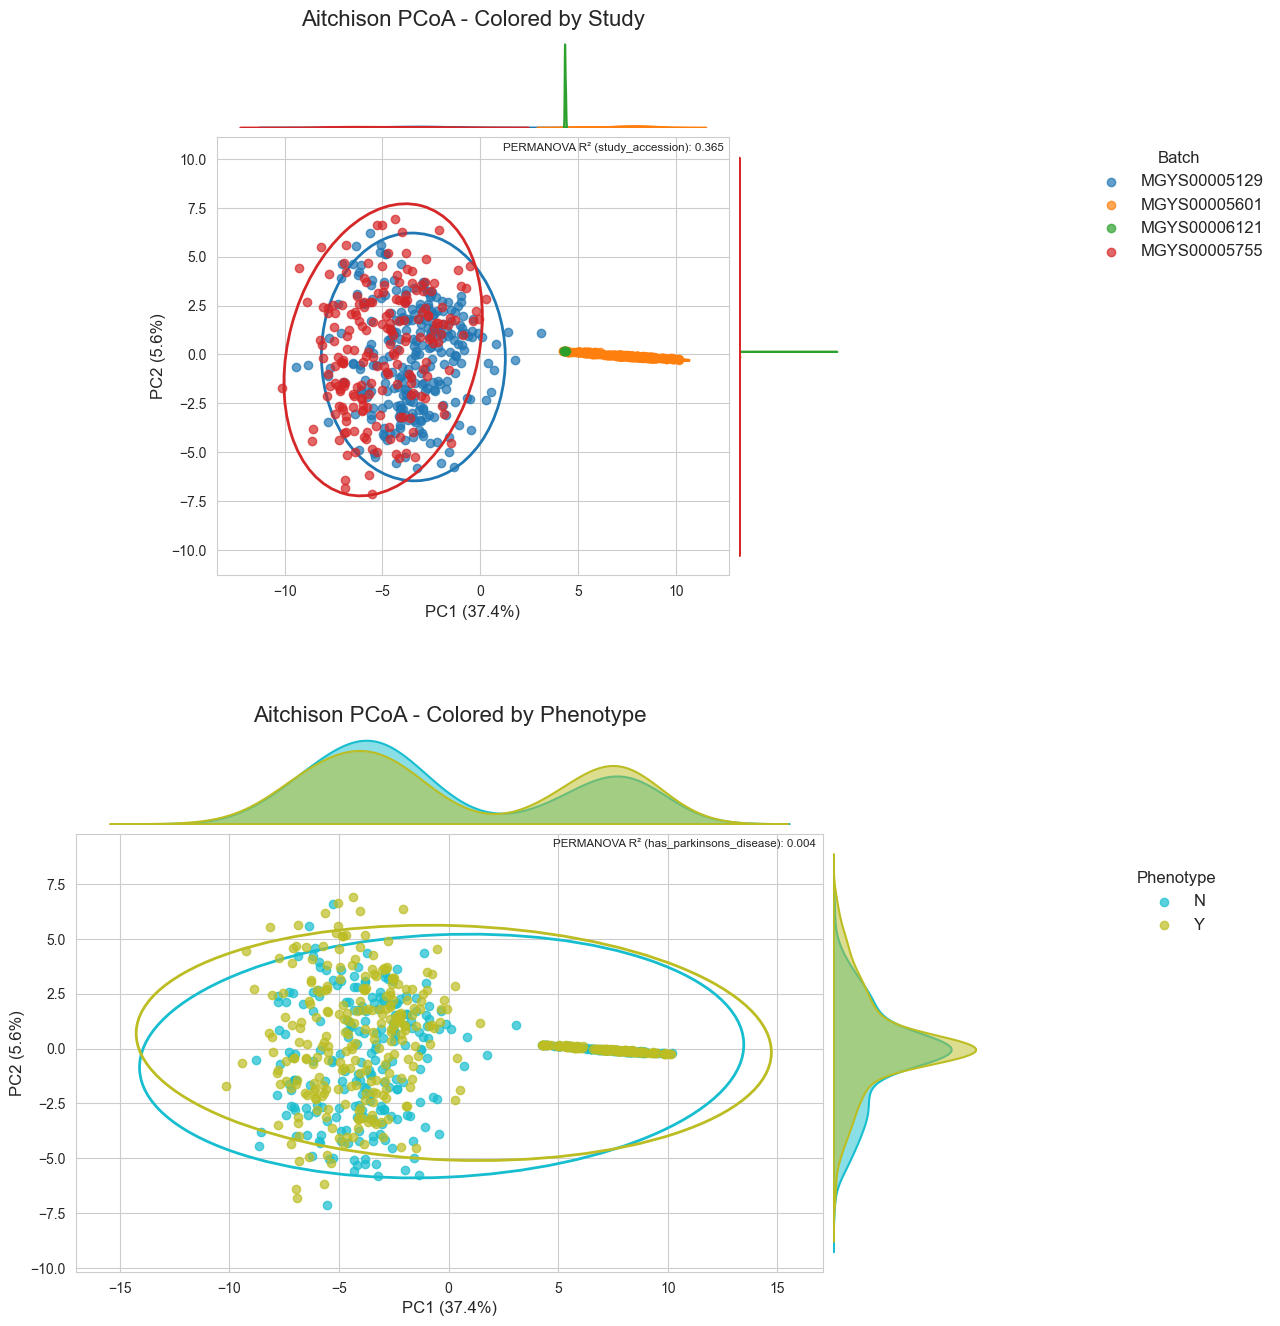

In [28]:
# Define figure
from abaco.dataloader import DataTransform

sns.set_style("whitegrid")
fig = plt.figure(figsize=(24, 16))
fig.suptitle("", fontsize=16, y=0.97)

gs = GridSpec(2, 1, figure=fig, wspace=0.4, hspace=0.3)

top_palette = sns.color_palette("tab10", n_colors=9)
bottom_palette = sns.color_palette("tab10", n_colors=10)[::-1][:9]

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

data_clr = DataTransform(df_parkinson, factors=[id_col, batch_col, bio_col], count=True)

data_pcoa, data_exp = pcoa_aitchison(
    data_clr, sample_label=id_col, batch_label=batch_col, bio_label=bio_col
)

plot_pcoa_2(
    data_pcoa,
    group_col=batch_col,
    df=data_clr,
    sample_label=id_col,
    ax=ax1,
    explained=data_exp,
    palette=top_palette,
    title="Aitchison PCoA - Colored by Study",
    show_legend=False,
)

handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Batch",
    loc="upper right",
    frameon=False,
    bbox_to_anchor=(0.8, 0.82),
    fontsize=12,
    title_fontsize=12,
)

plot_pcoa_2(
    data_pcoa,
    group_col=bio_col,
    df=data_clr,
    sample_label=id_col,
    ax=ax2,
    explained=data_exp,
    palette=bottom_palette,
    title="Aitchison PCoA - Colored by Phenotype",
    show_legend=False,
)

handles, labels = ax2.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Phenotype",
    loc="upper right",
    frameon=False,
    bbox_to_anchor=(0.78, 0.37),
    fontsize=12,
    title_fontsize=12,
)

fig.subplots_adjust(right=0.85)

plt.show()

In [29]:
from abaco.ABaCo import metaABaCo
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create ABaCo model
abaco_model = metaABaCo(
    data=df_parkinson,
    n_bios=2,
    bio_label=bio_col,
    n_batches=4,
    batch_label=batch_col,
    n_features=df_parkinson.select_dtypes(include="number").shape[1],
    # prior="VMM",
    device=device,
    epochs=[1000, 2000, 1000],
)

abaco_model.fit(
    seed=42,
    w_cluster_penalty=0.1,  # 0.1
    phase_1_vae_lr=1e-3,  # 1e-3
    phase_2_vae_lr=1e-3,  # 1e-3
    phase_3_vae_lr=1e-7,  # 1e-7
    adv_lr=1e-4,  # 1e-4
    disc_lr=1e-4,
)  # 1e-4

Training: VAE for learning meaningful embeddings: 100%|██████████| 1000/1000 [00:24<00:00, 41.13it/s, bio_penalty=0.5984, clustering_loss=0.0222, elbo=89.4064, epoch=999/1001, vae_loss=90.0271] 
Training: Embeddings batch effect correction using adversrial training: 100%|██████████| 2000/2000 [01:02<00:00, 31.96it/s, adv_loss=-1.1196, bio_penalty=0.6824, clustering_loss=0.0222, disc_loss=1.1196, elbo=91.4711, epoch=1999/2001, vae_loss=92.1758]  
Training: VAE decoder with masked batch labels: 100%|██████████| 1000/1000 [00:18<00:00, 52.93it/s, cycle_loss=0.0000, epoch=1000/1000, vae_loss=153.0820]


/Users/anglup/GitHub/mgnipy/.venv/lib/python3.11/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/var/folders/3d/vpv9_sk51c584kypm0w04hmh0000gp/T/ipykernel_64050/127281214.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  explained_dict = {"PC1": explained[0], "PC2": explained[1]}


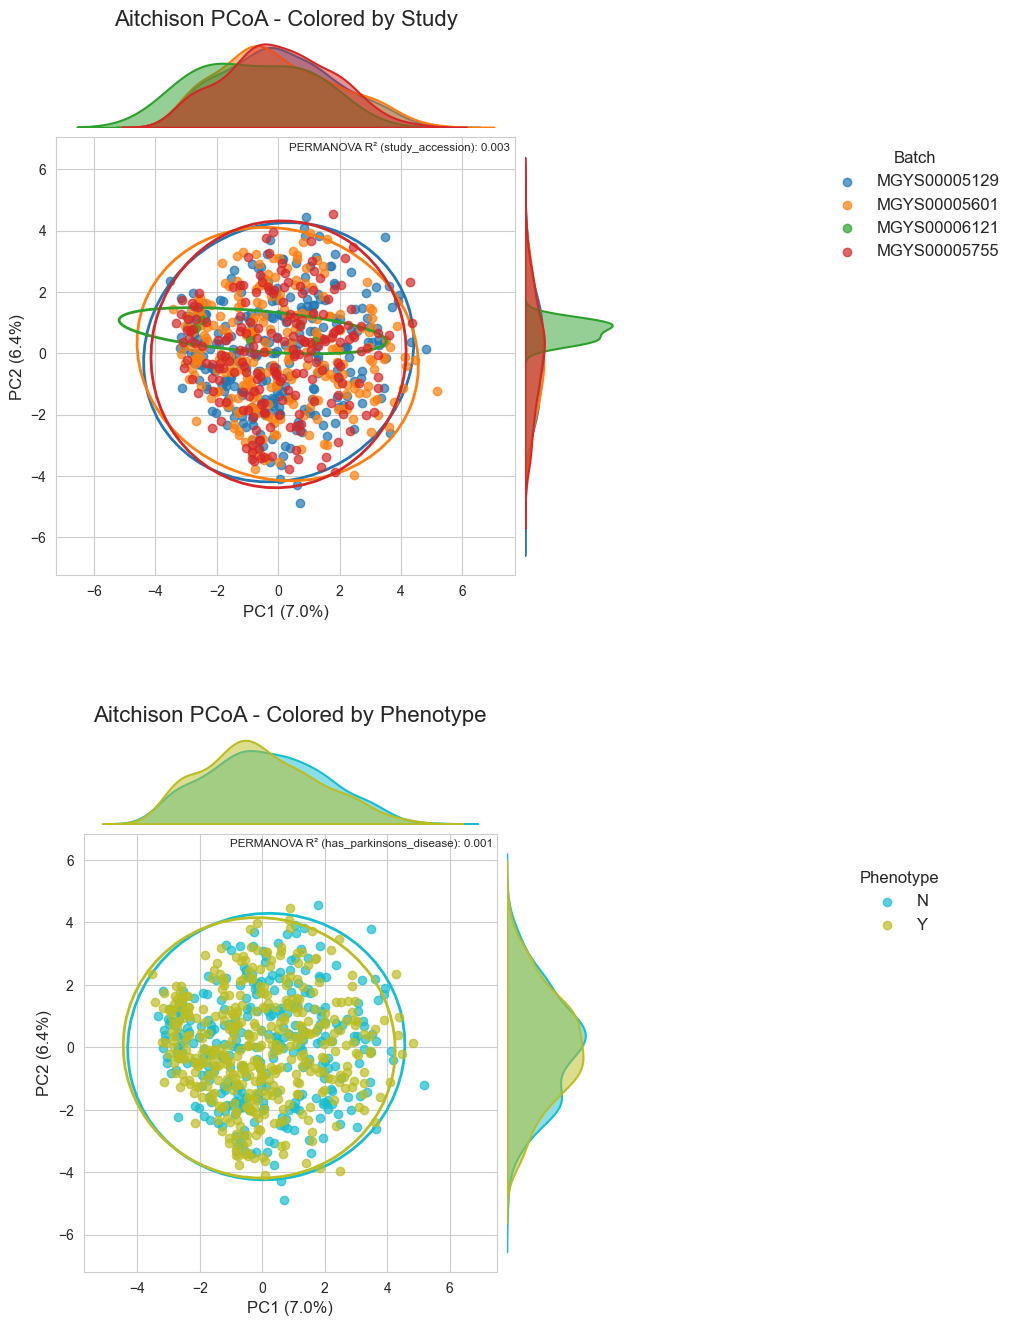

In [38]:
# Reconstruct the dataset using the trained ABaCo model
corrected_dataset = abaco_model.correct(seed=42)

sns.set_style("whitegrid")
fig = plt.figure(figsize=(24, 16))
fig.suptitle("", fontsize=16, y=0.97)

gs = GridSpec(2, 1, figure=fig, wspace=0.4, hspace=0.3)

top_palette = sns.color_palette("tab10", n_colors=9)
bottom_palette = sns.color_palette("tab10", n_colors=10)[::-1][:9]

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

corrected_data_clr = DataTransform(
    corrected_dataset, factors=[id_col, batch_col, bio_col], count=True
)

data_pcoa, data_exp = pcoa_aitchison(
    corrected_data_clr, sample_label=id_col, batch_label=batch_col, bio_label=bio_col
)

plot_pcoa_2(
    data_pcoa,
    group_col=batch_col,
    df=corrected_data_clr,
    sample_label=id_col,
    ax=ax1,
    explained=data_exp,
    palette=top_palette,
    title="Aitchison PCoA - Colored by Study",
    show_legend=False,
)

handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Batch",
    loc="upper right",
    frameon=False,
    bbox_to_anchor=(0.77, 0.82),
    fontsize=12,
    title_fontsize=12,
)

plot_pcoa_2(
    data_pcoa,
    group_col=bio_col,
    df=corrected_data_clr,
    sample_label=id_col,
    ax=ax2,
    explained=data_exp,
    palette=bottom_palette,
    title="Aitchison PCoA - Colored by Phenotype",
    show_legend=False,
)

handles, labels = ax2.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Phenotype",
    loc="upper right",
    frameon=False,
    bbox_to_anchor=(0.745, 0.37),
    fontsize=12,
    title_fontsize=12,
)

fig.subplots_adjust(right=0.85)

plt.show()

In [39]:
import abaco.metrics as metrics

print("kBET results before batch correction:")
print(metrics.kBET(data_clr, batch_col))
print("\niLISI results before batch correction:")
print(metrics.iLISI_norm(data_clr, batch_col))
print("\nbatch ASW results before batch correction:")
print(1 - metrics.ASW(data_clr, batch_col))
print("\nbatch ARI results before batch correction:")
print(1 - metrics.ARI(data_clr, batch_col))

print("\n\nkBET results after batch correction:")
print(metrics.kBET(corrected_data_clr, batch_col))
print("\niLISI results after batch correction:")
print(metrics.iLISI_norm(corrected_data_clr, batch_col))
print("\nbatch ASW results after batch correction:")
print(1 - metrics.ASW(corrected_data_clr, batch_col))
print("\nbatch ARI results after batch correction:")
print(1 - metrics.ARI(corrected_data_clr, batch_col))

kBET results before batch correction:
0.0

iLISI results before batch correction:
0.13268697878555313

batch ASW results before batch correction:
0.953883374113421

batch ARI results before batch correction:
0.4622274613227778


kBET results after batch correction:
0.6652949245541838

iLISI results after batch correction:
0.6158093946897032

batch ASW results after batch correction:
1.0675915256142616

batch ARI results after batch correction:
1.002052070514109


batch corrected. 

---

# TODO

working with the corrected dataset

as anndata

In [32]:
from skbio.stats.composition import clr
import anndata as ad

adata = ad.AnnData(corrected_dataset.iloc[:, 3:], obs=corrected_dataset.iloc[:, :3])
adata.layers["totals"] = np.array([adata.to_df().sum(axis=1)] * adata.n_vars).T
adata.layers["normalized_X"] = adata.to_df() / adata.layers["totals"]
adata.layers["clr_X"] = clr(
    np.where(adata.layers["normalized_X"] > 0, adata.layers["normalized_X"], 1e-10)
)

/Users/anglup/.pyenv/versions/3.11.7/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [33]:
# Diversity: Number of unique taxa per sample as new metadata
adata.obs["X_numtaxa"] = (adata.X > 0).sum(axis=1)

# Diversity with correction: Chao1 estimator
# Chao1 = num observed taxa + (num singletons / (2 x num doubletons))
num_singletons = (adata.X == 1).sum(axis=1)
num_doubletons = (adata.X == 2).sum(axis=1)
adata.obs["X_chao1"] = (adata.X > 0).sum(axis=1) + (
    num_singletons / (2 * num_doubletons)
)

# Diversity: Shannon index H = -sum(p_i * log(p_i)), entropy
from scipy.stats import entropy

adata.obs["X_shannon"] = entropy(
    adata.layers["normalized_X"], nan_policy="omit", axis=1
)

# Evenness: Pielou evenness index P = H/H_max, H_max = ln(num species)
adata.obs["X_pielou"] = adata.obs["X_shannon"] / np.log(adata.obs["X_numtaxa"])

# Diversity: simpson index lambda = sum(p_i ^2)
adata.obs["X_simpson"] = (adata.layers["normalized_X"] ** 2).sum(axis=1)

# Diversity: inverse simpson index D = 1/lambda
adata.obs["X_inv_simpson"] = 1 / adata.obs["X_simpson"]

/var/folders/3d/vpv9_sk51c584kypm0w04hmh0000gp/T/ipykernel_64050/30217636.py:9: RuntimeWarning: divide by zero encountered in divide
  num_singletons / (2 * num_doubletons)
/var/folders/3d/vpv9_sk51c584kypm0w04hmh0000gp/T/ipykernel_64050/30217636.py:9: RuntimeWarning: invalid value encountered in divide
  num_singletons / (2 * num_doubletons)


[None]

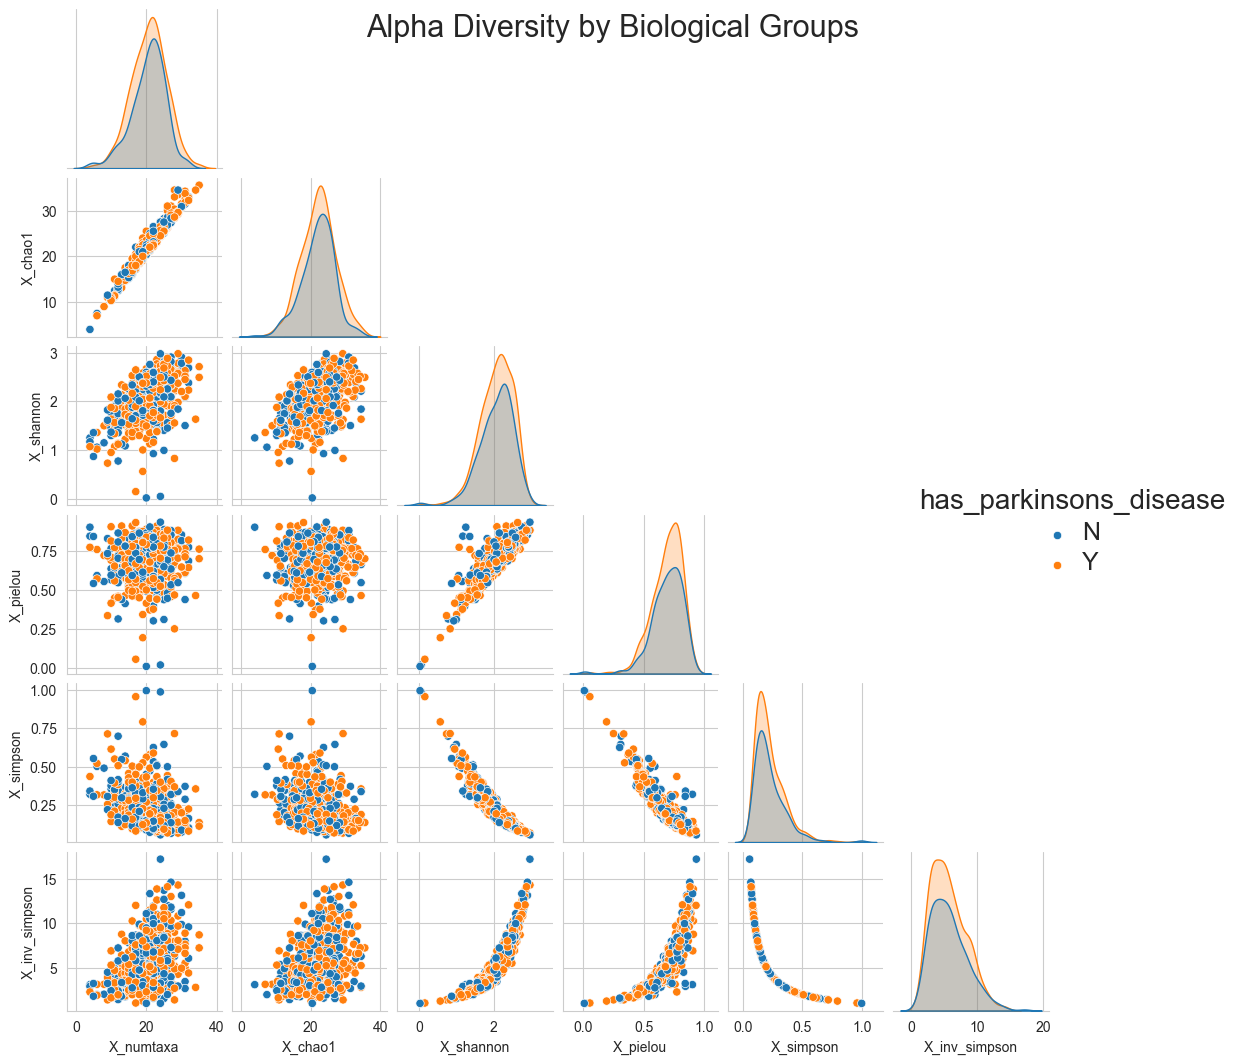

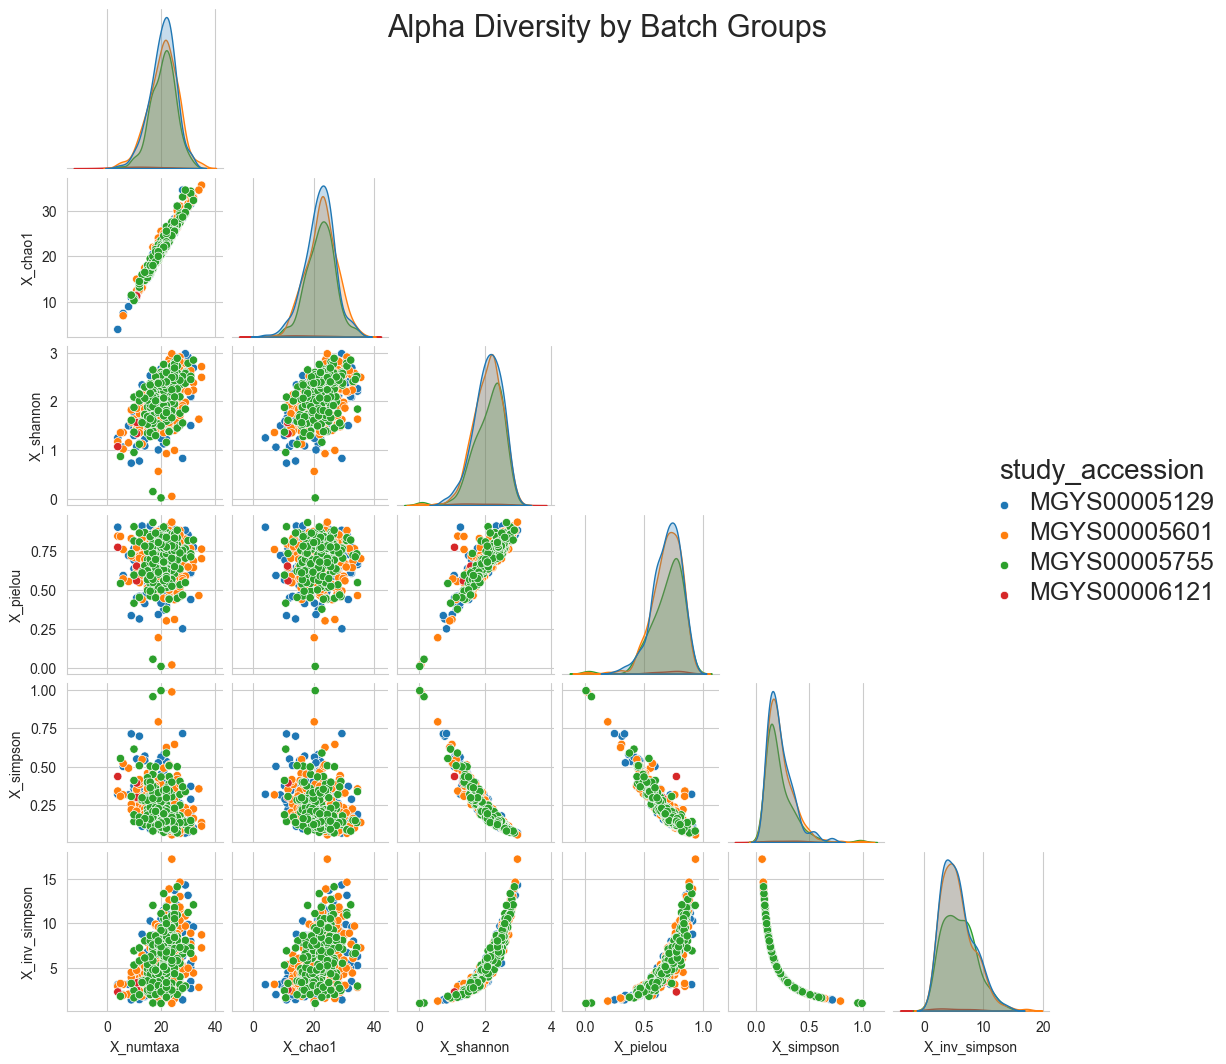

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# preparing the df for vis
df_alphas = adata.obs[
    [
        "X_numtaxa",
        "X_chao1",
        "X_shannon",
        "X_pielou",
        "X_simpson",
        "X_inv_simpson",
        batch_col,
        bio_col,
    ]
].copy()

# plotting by bio groups
g1 = sns.pairplot(df_alphas, hue=bio_col, corner=True, height=1.8)
g1.figure.suptitle("Alpha Diversity by Biological Groups", fontsize=22)
plt.setp(g1._legend.get_texts(), fontsize=18)
plt.setp(g1._legend.get_title(), fontsize=20)

g2 = sns.pairplot(df_alphas, hue=batch_col, corner=True, height=1.8)
g2.figure.suptitle("Alpha Diversity by Batch Groups", fontsize=22)
plt.setp(g2._legend.get_texts(), fontsize=18)
plt.setp(g2._legend.get_title(), fontsize=20)

In [35]:
adata.obs.groupby("has_parkinsons_disease")[
    ["X_numtaxa", "X_chao1", "X_shannon", "X_pielou", "X_simpson", "X_inv_simpson"]
].mean()

/var/folders/3d/vpv9_sk51c584kypm0w04hmh0000gp/T/ipykernel_64050/923532370.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("has_parkinsons_disease")[


,X_numtaxa,X_chao1,X_shannon,X_pielou,X_simpson,X_inv_simpson
has_parkinsons_disease,,,,,,
N,20.522293,inf,2.075127,0.695025,0.224142,5.733210
Y,20.722892,inf,2.079730,0.692762,0.223700,5.665872


In [36]:
oj = taxo.obs_metadata()

oj[oj["sample_accession"] == "SAMN28061739"][disease_status_columns.keys()]

,host_phenotype,host disease status,parkinson,Case_status
_mgnipy_runs_accs,,,,
ERZ23877886,None,None,None,Control


In [37]:
new_taxo.mgnify_studies.ids

['MGYS00006759',
 'MGYS00006121',
 'MGYS00005601',
 'MGYS00005129',
 'MGYS00005755']